In [1]:
import numpy as np
import matplotlib.pyplot as plt


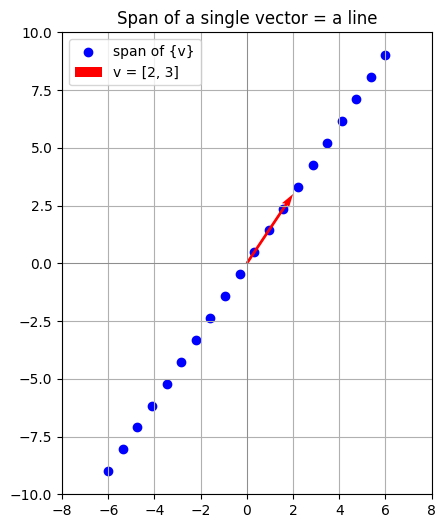

In [2]:
# Vector span of a single vector in 2d space is always a line

v = np.array([2, 3])

# Many scalar multiples
scalars = np.linspace(-3, 3, 20)
points = np.array([c * v for c in scalars])

plt.figure(figsize=(6, 6))
plt.scatter(points[:, 0], points[:, 1], color='blue', label='span of {v}')
plt.quiver(0, 0, v[0], v[1], angles='xy', scale_units='xy', scale=1, color='red', label='v = [2, 3]')
plt.axhline(0, color='gray', linewidth=0.5)
plt.axvline(0, color='gray', linewidth=0.5)
plt.grid(True)
plt.gca().set_aspect('equal')
plt.legend()
plt.title("Span of a single vector = a line")
plt.xlim(-8, 8)
plt.ylim(-10, 10)
plt.show()

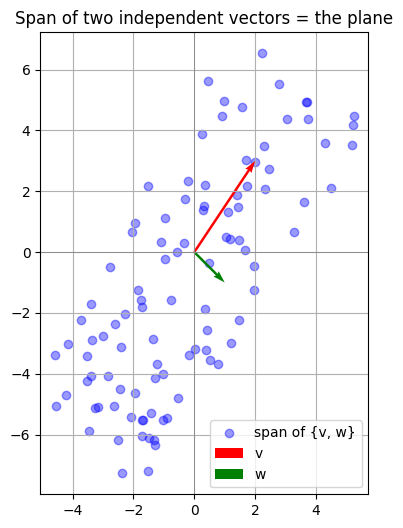

In [11]:
# Span for two linearly independent vectors is the entire 2d plane

v = np.array([2, 3])
w = np.array([1, -1])

# Many random linear combinations
coefficients = np.random.uniform(-2, 2, (100, 2))   # 200 pairs of (a, b)
points = np.array([a * v + b * w for a, b in coefficients])

plt.figure(figsize=(6, 6))
plt.scatter(points[:, 0], points[:, 1], color='blue', alpha=0.4, label='span of {v, w}')
plt.quiver(0, 0, v[0], v[1], angles='xy', scale_units='xy', scale=1, color='red', label='v')
plt.quiver(0, 0, w[0], w[1], angles='xy', scale_units='xy', scale=1, color='green', label='w')
plt.axhline(0, color='gray', linewidth=0.5)
plt.axvline(0, color='gray', linewidth=0.5)
plt.grid(True)
plt.gca().set_aspect('equal')
plt.legend()
plt.title("Span of two independent vectors = the plane")
plt.show()

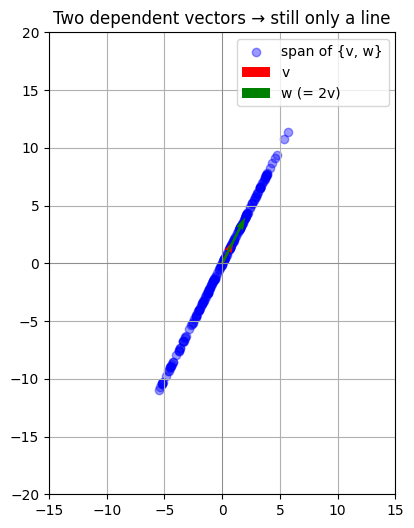

In [13]:
# Span of two dependent vectors is also a line

v = np.array([1,2])
w = np.array([2,4])

coefficients = np.random.uniform(-2,2,(200,2))
points = np.array([ a * v + b * w for a, b in coefficients])

plt.figure(figsize=(6, 6))
plt.scatter(points[:, 0], points[:, 1], color='blue', alpha=0.4, label='span of {v, w}')
plt.quiver(0, 0, v[0], v[1], angles='xy', scale_units='xy', scale=1, color='red', label='v')
plt.quiver(0, 0, w[0], w[1], angles='xy', scale_units='xy', scale=1, color='green', label='w (= 2v)')
plt.axhline(0, color='gray', linewidth=0.5)
plt.axvline(0, color='gray', linewidth=0.5)
plt.grid(True)
plt.gca().set_aspect('equal')
plt.legend()
plt.title("Two dependent vectors → still only a line")
plt.xlim(-15, 15)
plt.ylim(-20, 20)
plt.show()


In [15]:
# Indentfying whether the set of vectors are linearly depednent or independent

def is_set_linear_independent(vectors):
    matrix = np.column_stack(vectors)
    rank = np.linalg.matrix_rank(matrix)
    return rank == len(vectors)

print(is_set_linear_independent([np.array([1, 0]), np.array([0, 1])]))           # True  — basis
print(is_set_linear_independent([np.array([1, 0])]))                              # True (alone), but doesn't span 2D
print(is_set_linear_independent([np.array([1, 1]), np.array([2, 2])]))            # False — dependent
print(is_set_linear_independent([np.array([1, 0]), np.array([0, 1]), np.array([1, 1])]))  # False — 3 in 2D
print(is_set_linear_independent([np.array([1, 1]), np.array([1, -1])]))    # True  — basis


True
True
False
False
True


In [19]:
# Buildign 2D vector from a basis vector

# Basis for 2D
b1 = np.array([1, 1])
b2 = np.array([1, -1])

# Target vectors to express in this basis
targets = [np.array([3, 5]), np.array([2, 0]), np.array([-1, 4])]

# Stack b1 and b2 as columns of a matrix
B = np.column_stack([b1, b2])

for t in targets:
    coeffs = np.linalg.solve(B, t)
    a, b = coeffs
    print(a,b)
    # Verify by reconstructing
    reconstructed = a * b1 + b * b2
    print(f"t = {t}")
    print(f"  coefficients in basis: a = {a:.2f}, b = {b:.2f}")
    print(f"  reconstructed: {reconstructed}\n")

4.0 -1.0
t = [3 5]
  coefficients in basis: a = 4.00, b = -1.00
  reconstructed: [3. 5.]

1.0 1.0
t = [2 0]
  coefficients in basis: a = 1.00, b = 1.00
  reconstructed: [2. 0.]

1.5 -2.5
t = [-1  4]
  coefficients in basis: a = 1.50, b = -2.50
  reconstructed: [-1.  4.]



In [26]:
# Applying rank, dependence and basis in ML/Quant

# Use case 1 : Detecting redundant features (Multicollinearity)

# Imagine a stocks observed over 6 days, with 4 features each
# Feature 1: daily return
# Feature 2: 100 × daily return (just a re-scaling — completely redundant)
# Feature 3: volume (independent info)
# Feature 4: volatility (independent info)

returns = np.random.uniform(-0.2,0.2,6)
returns_pct = returns * 100
volume     = np.random.uniform(1e6, 5e6, 6)
volatility = np.random.uniform(0.01, 0.05, 6)

X = np.column_stack([returns, returns_pct, volume, volatility])
print("Shape of X", X.shape)
print("Rank of feature matrix", np.linalg.matrix_rank(X))
print("Number of features:", X.shape[1])


# The feature matrix had four features so the rank should be four 
# but since one of the feature was a scaled version of the other it collapsed into one


Shape of X (6, 4)
Rank of feature matrix 3
Number of features: 4


In [28]:
# Use case 2 : Identifying near dependent features


market = np.random.normal(0, 0.01, 30)

stock_a = market + np.random.normal(0, 0.001, 30)   
stock_b = market + np.random.normal(0, 0.001, 30)   
stock_c = market + np.random.normal(0, 0.001, 30)   
stock_d = np.random.normal(0, 0.01, 30)             
stock_e = np.random.normal(0, 0.01, 30)             

# Stack as a feature matrix: rows = days, cols = stocks
X = np.column_stack([stock_a, stock_b, stock_c, stock_d, stock_e])
print("Shape:", X.shape)
print("Rank :", np.linalg.matrix_rank(X))

Shape: (30, 5)
Rank : 5


In [31]:
def cosine_similarity(v1, v2):
    return np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))

labels = ['A', 'B', 'C', 'D', 'E']
print("\nPairwise cosine similarity:")
for i in range(5):
    for j in range(i + 1, 5):
        sim = cosine_similarity(X[:, i], X[:, j])
        print(f"  {labels[i]}-{labels[j]}: {sim:+.3f}")

# Via consine similairty we could clearly see that stocks paired between A,B,C are highly similar,
# and stocks  paired from d, e are less simialr these primairliy due to later changes added to them despite their
# base price being similar.

    



Pairwise cosine similarity:
  A-B: +0.987
  A-C: +0.989
  A-D: +0.267
  A-E: +0.080
  B-C: +0.991
  B-D: +0.259
  B-E: +0.053
  C-D: +0.274
  C-E: +0.071
  D-E: +0.418


In [33]:
# Define two "factor vectors" — 6-day return patterns of known factors
market_factor   = np.array([0.01, 0.02, -0.01, 0.03, 0.01, 0.02])    # broad market move
momentum_factor = np.array([-0.02, -0.01, 0.00, 0.01, 0.02, 0.03])   # upward trend

# A specific stock's 6-day returns
stock_returns = np.array([0.00, 0.01, -0.01, 0.04, 0.03, 0.05])

# Pretend we only see the first 2 days for both stocks and factors
market_2d   = market_factor[:2]
momentum_2d = momentum_factor[:2]
stock_2d    = stock_returns[:2]

# Stack factors as columns
B = np.column_stack([market_2d, momentum_2d])
print("B =\n", B)

# Solve exactly using the basis-coordinate finder you just learned
coeffs = np.linalg.solve(B, stock_2d)
a, b = coeffs
print(f"\nMarket exposure (a):   {a:.3f}")
print(f"Momentum exposure (b): {b:.3f}")

# Verify by reconstructing
reconstructed = a * market_2d + b * momentum_2d
print(f"\nOriginal:      {stock_2d}")
print(f"Reconstructed: {reconstructed}")

B =
 [[ 0.01 -0.02]
 [ 0.02 -0.01]]

Market exposure (a):   0.667
Momentum exposure (b): 0.333

Original:      [0.   0.01]
Reconstructed: [0.   0.01]


In [34]:
# An overly determined system here an exact solution for a and b dont exist so if we look for 
# a coefficeint where the error is minimized    

B_full = np.column_stack([market_factor, momentum_factor])
print("B_full shape:", B_full.shape)   # (6, 2)


# The error hapenned becuase the matrix is not square we will fix these issues in the next phase.

# Try the same solve
try:
    coeffs = np.linalg.solve(B_full, stock_returns)
except np.linalg.LinAlgError as e:
    print(f"\nError: {e}")
    print("→ np.linalg.solve only works for square matrices!")

B_full shape: (6, 2)

Error: Last 2 dimensions of the array must be square
→ np.linalg.solve only works for square matrices!
